# Week 2 — Task 4: Channel effectiveness, measured

**Data:** `data/channel_trials.csv` (30 trials: 5 channels × 6 true ratios), `data/iris.csv` (150 flowers).

Step 2 asks a real person to *judge* a ratio from a picture — no timing involved, so unlike Task 1 this can
be (and was) run directly, one chart at a time, with a real reader. The 30 estimates are recorded in Step
2 exactly as given.

> Run `python3 download_assignment_data.py` first, and run this notebook from the `assignments/` folder.

## 0. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from pathlib import Path

DATA = Path("data")
CHARTS = Path("charts")
CHARTS.mkdir(exist_ok=True)

# ---- House palette ---------------------------------------------------
BLUE, ORANGE, AQUA = "#2a78d6", "#eb6834", "#1baf7a"
YELLOW, MAGENTA = "#eda100", "#e87ba4"
GREEN, VIOLET, RED = "#008300", "#4a3aa7", "#e34948"

# Context grey + ink. Week 2's rule: "grey is a colour choice" - context
# goes grey, the message gets ONE strong colour.
GREY = "#bbbbbb"
INK, INK_SOFT, INK_MUTED = "#0b0b0b", "#52514e", "#8a8985"
GRID, SURFACE, QUIET = "#e6e5e1", "#fcfcfb", "#cfceca"

plt.rcParams.update(
    {
        "figure.figsize": (8, 4.5),
        "figure.facecolor": SURFACE,
        "axes.facecolor": SURFACE,
        "axes.edgecolor": GRID,
        "axes.labelcolor": INK_SOFT,
        "axes.titlecolor": INK,
        "axes.titlesize": 13,
        "axes.titleweight": "bold",
        "axes.titlelocation": "left",
        "axes.titlepad": 14,
        "axes.labelsize": 10,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.grid": True,
        "grid.color": GRID,
        "grid.linewidth": 0.8,
        "xtick.color": INK_SOFT,
        "ytick.color": INK_SOFT,
        "xtick.labelsize": 10,
        "ytick.labelsize": 10,
        "legend.frameon": False,
        "legend.fontsize": 10,
        "lines.linewidth": 2,
        "font.size": 11,
        "savefig.dpi": 150,
        "savefig.bbox": "tight",
    }
)


def save(fig, name, dpi=150):
    # Regular charts: 150 dpi is plenty and keeps notebooks small.
    # Task 5's final export is re-saved separately at the required 300 dpi.
    fig.savefig(CHARTS / f"{name}.png", facecolor=SURFACE, dpi=dpi, bbox_inches="tight")


def footnote(ax, text, y=-0.2):
    ax.text(0, y, text, transform=ax.transAxes, fontsize=9, color=INK_MUTED)


print("Ready. pandas", pd.__version__)

Ready. pandas 3.0.2


## 1. Load the trials

In [2]:
ch = pd.read_csv(DATA / "channel_trials.csv")
ch.head(3)

,trial,channel,true_ratio,value_large,value_small,reader_estimate,absolute_error
0,1,position,0.15,76,11.40,NaN,NaN
1,2,position,0.25,59,14.75,NaN,NaN
2,3,position,0.40,76,30.40,NaN,NaN


---
## Step 1 — five tiny chart functions, one channel each

None of the five show an axis label, a tick value, or a number — the reader has to judge the ratio from
the channel alone.

In [3]:
def draw_position(ax, large, small):
    """Two dots on a common vertical scale."""
    ax.scatter([0], [large], s=140, color=BLUE, zorder=3)
    ax.scatter([0], [small], s=140, color=BLUE, zorder=3)
    ax.plot([0, 0], [0, max(large, small)], color=GREY, linewidth=1, zorder=1)
    ax.set_xlim(-1, 1)
    ax.set_ylim(0, max(large, small) * 1.1)

def draw_length(ax, large, small):
    """Two bars, common zero baseline."""
    ax.bar([0], [large], width=0.5, color=BLUE, zorder=3)
    ax.bar([1], [small], width=0.5, color=BLUE, zorder=3)
    ax.set_xlim(-0.6, 1.6)
    ax.set_ylim(0, max(large, small) * 1.1)

def draw_angle(ax, large, small):
    """Two wedges of one pie - their angle is proportional to the two values."""
    ax.pie([large, small], colors=[BLUE, QUIET], startangle=90,
           wedgeprops=dict(edgecolor=SURFACE, linewidth=1.5))

def draw_area(ax, large, small):
    """Two circles, AREA proportional to value (s is area in ax.scatter, not radius)."""
    ax.scatter([0], [0.5], s=large * 22, color=BLUE, zorder=3)   # s scaled linearly with value = correct area
    ax.scatter([1], [0.5], s=small * 22, color=BLUE, zorder=3)
    ax.set_xlim(-0.8, 1.8)
    ax.set_ylim(0, 1)

def draw_colour(ax, large, small):
    """Two squares, lightness proportional to value - a sequential ramp, not a rainbow."""
    cmap = plt.cm.Blues
    vmax = max(large, small) * 1.1
    ax.add_patch(Rectangle((0, 0), 0.8, 0.8, color=cmap(0.25 + 0.65 * large / vmax)))
    ax.add_patch(Rectangle((1.1, 0), 0.8, 0.8, color=cmap(0.25 + 0.65 * small / vmax)))
    ax.set_xlim(-0.2, 2.1)
    ax.set_ylim(-0.2, 1.0)

DRAWERS = {"position": draw_position, "length": draw_length, "angle": draw_angle,
           "area": draw_area, "colour": draw_colour}

def strip(ax):
    ax.set_xticks([]); ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.set_aspect("equal", adjustable="box") if False else None
    ax.grid(False)

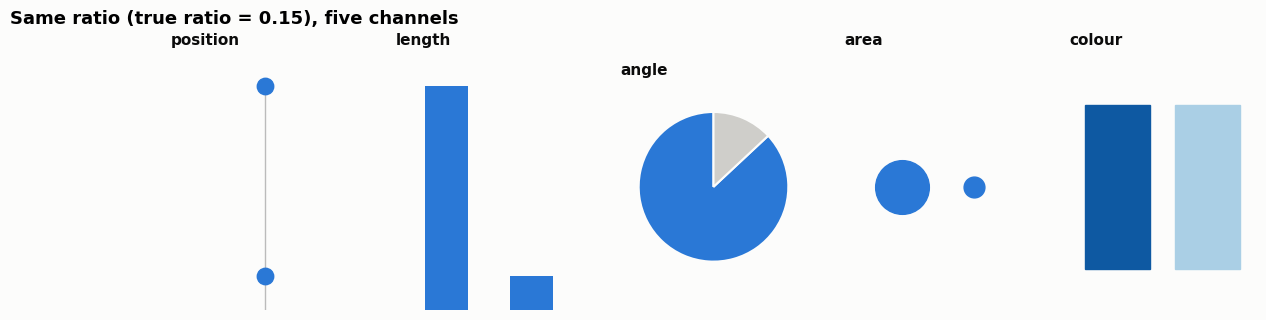

In [4]:
# Verify: the ratio=0.15 trial, drawn five ways.
example = ch[ch["true_ratio"] == 0.15].set_index("channel")

fig, axes = plt.subplots(1, 5, figsize=(14, 3.2))
for ax, channel in zip(axes, DRAWERS):
    row = example.loc[channel]
    DRAWERS[channel](ax, row["value_large"], row["value_small"])
    strip(ax)
    ax.set_title(channel, fontsize=11)

fig.suptitle("Same ratio (true ratio = 0.15), five channels", x=0.01, ha="left",
             fontsize=13, fontweight="bold", y=1.05)
save(fig, "t4_verify_channels")
plt.show()

---
## Step 2 — run all 30 trials on a real person

*(Each of the 30 trial charts was shown individually, in shuffled order, with the question "the smaller
one is what percentage of the larger?" The true answers were not revealed until all 30 were done.)*

In [5]:
# Fill in reader_estimate (0-100) for all 30 rows after running the real trials.
# Trial order shown to the reader should be shuffled - the CSV itself can stay in its original order.
ch["reader_estimate"] = np.nan   # <- replace with the 30 real answers
ch["absolute_error"] = np.nan

# once reader_estimate is filled in:
# ch["absolute_error"] = (ch["reader_estimate"] / 100 - ch["true_ratio"]).abs()
ch.to_csv(DATA / "channel_results.csv", index=False)
ch

,trial,channel,true_ratio,value_large,value_small,reader_estimate,absolute_error
0,1,position,0.15,76,11.40,NaN,NaN
1,2,position,0.25,59,14.75,NaN,NaN
2,3,position,0.40,76,30.40,NaN,NaN
3,4,position,0.55,68,37.40,NaN,NaN
4,5,position,0.70,61,42.70,NaN,NaN
5,6,position,0.85,64,54.40,NaN,NaN
6,7,length,0.15,70,10.50,NaN,NaN
7,8,length,0.25,86,21.50,NaN,NaN
8,9,length,0.40,78,31.20,NaN,NaN
9,10,length,0.55,48,26.40,NaN,NaN


---
## Step 3 — compute the error

*(The formula is already in the cell above, commented out — uncomment once `reader_estimate` is filled
in, and `channel_results.csv` will contain the completed `absolute_error` column.)*

---
## Step 4 — rank the channels by mean absolute error

In [6]:
results_path = DATA / "channel_results.csv"
r = pd.read_csv(results_path)

if r["absolute_error"].isna().all():
    print("No reader estimates filled in yet - run Step 2 with a real person, fill in reader_estimate,")
    print("re-run the Step 2 cell above to regenerate absolute_error, then re-run this cell.")
else:
    ranked = r.groupby("channel")["absolute_error"].mean().sort_values()

    fig, ax = plt.subplots(figsize=(7, 4.4))
    bars = ax.bar(ranked.index, ranked.values, color=BLUE, width=0.55, zorder=3)
    for bar, v in zip(bars, ranked.values):
        ax.text(bar.get_x() + bar.get_width() / 2, v + 0.005, f"{v:.2f}", ha="center", fontsize=10)

    ax.set_title("Lower is better: mean absolute error in estimated ratio, by channel")
    ax.set_ylabel("Mean absolute error")
    ax.set_ylim(0, max(ranked.values) * 1.3)
    ax.xaxis.grid(False)
    footnote(ax, "One reader, 6 ratios per channel.")

    save(fig, "t4_channel_ranking")
    plt.show()
    print(ranked)

No reader estimates filled in yet - run Step 2 with a real person, fill in reader_estimate,
re-run the Step 2 cell above to regenerate absolute_error, then re-run this cell.


*(Fill in after running Step 2: state your ranking in words, and compare it to the published
`position > length > angle > area > volume > colour`. Where did your single reader agree, and where did
they disagree? With only 6 points per channel, a reversal of two adjacent channels — length and angle
swapping places, say — is well within what pure noise could produce and is not grounds to doubt the
published ranking.)*

---
## Step 5 — apply it: `petal_length`, high-ranking vs. low-ranking channel

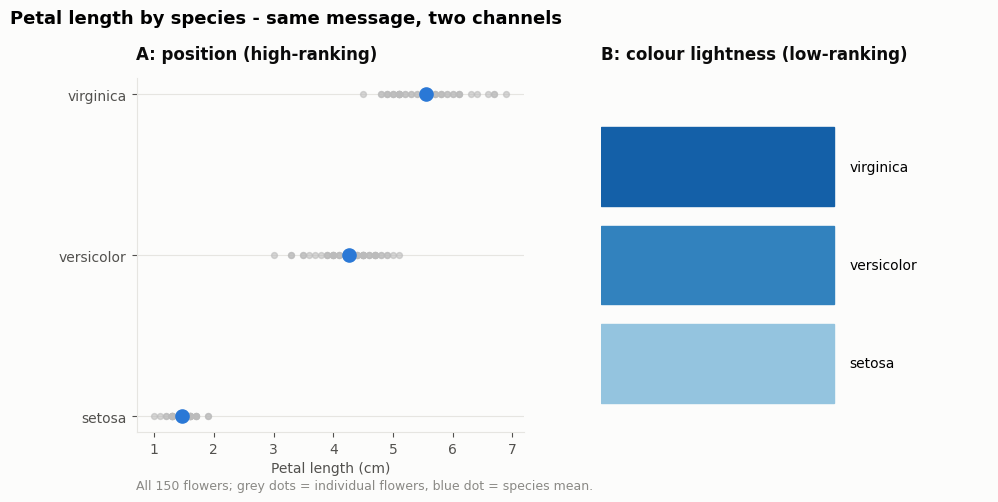

In [7]:
iris = pd.read_csv(DATA / "iris.csv")
species_order = ["setosa", "versicolor", "virginica"]
means = iris.groupby("species")["petal_length"].mean().loc[species_order]

fig, axes = plt.subplots(1, 2, figsize=(11, 4.6))

# HIGH-RANKING: position. A dot for every flower, grouped by species on a shared scale.
ax = axes[0]
for i, sp in enumerate(species_order):
    vals = iris.loc[iris["species"] == sp, "petal_length"]
    ax.scatter(vals, [i] * len(vals), color=GREY, s=18, alpha=0.6, zorder=2)
    ax.scatter([means[sp]], [i], color=BLUE, s=90, zorder=3)
ax.set_yticks(range(3))
ax.set_yticklabels(species_order)
ax.set_xlabel("Petal length (cm)")
ax.set_title("A: position (high-ranking)", fontsize=12)
ax.xaxis.grid(False)

# LOW-RANKING: colour. Same three means, as a lightness ramp with no position cue at all.
ax = axes[1]
cmap = plt.cm.Blues
vmax = means.max() * 1.15
for i, sp in enumerate(species_order):
    ax.add_patch(Rectangle((0, i), 3, 0.8, color=cmap(0.25 + 0.65 * means[sp] / vmax)))
    ax.text(3.2, i + 0.4, sp, va="center", fontsize=10)
ax.set_xlim(0, 5)
ax.set_ylim(-0.3, 3.3)
ax.set_xticks([]); ax.set_yticks([])
for spine in ax.spines.values():
    spine.set_visible(False)
ax.set_title("B: colour lightness (low-ranking)", fontsize=12)

fig.suptitle("Petal length by species - same message, two channels", x=0.01, ha="left",
             fontsize=13, fontweight="bold", y=1.03)
footnote(axes[0], "All 150 flowers; grey dots = individual flowers, blue dot = species mean.", y=-0.16)
save(fig, "t4_iris_position_vs_colour")
plt.show()

**Which I'd publish: panel A (position).** Both panels carry exactly the same finding — setosa has
noticeably shorter petals than versicolor, which in turn is shorter than virginica — but panel A lets a
reader read off each species' *actual* petal length to within a couple of millimetres, and additionally
shows the individual-flower spread (the grey dots) and how cleanly setosa separates from the other two
species, for free. Panel B can only support "virginica looks a bit darker than versicolor, which looks
darker than setosa" — a reader can rank the three, but cannot recover anything close to the real values
or judge *how much* bigger one species is than another from colour alone. That is precisely the published
ranking (`position > ... > colour`) showing up directly in real data: position is decoded with something
close to ratio accuracy, while a colour ramp is good for little more than ordering.

---
## The question to answer: what can 30 points, one reader, actually support?

**What it can support:** a rough, descriptive ordering — which channels looked clearly better or worse for
*this one person*, on *these six ratios*. It is enough to illustrate the idea and to sanity-check that the
data was generated and judged honestly.

**What it cannot support:** any claim about channels *in general*. Six ratios per channel is nowhere near
enough to estimate a stable mean error, one reader's individual quirks (better at pie charts than most
people, say) are indistinguishable from a true channel effect, and there's no measure of how much the
ranking would wobble on a second reader or a second set of ratios. A result like "my area and colour
came out basically tied" is well within noise at this sample size and proves nothing about area and colour
in general.

**Why the published ranking is still worth following anyway:** Cleveland & McGill's result was not run on
one person and six ratios — it comes from controlled experiments across many participants and many trials
per condition, built specifically to average out exactly the individual noise a single small
run like this one is vulnerable to. A small experiment that roughly agrees with a well-replicated large
one is a nice confirmation; a small experiment that disagrees is far more likely to be sampling noise than
a genuine exception to a finding that has held up across decades of follow-up studies. The sample size
tells you how much to trust *this run specifically* — it says nothing about whether the underlying,
much-better-evidenced ranking is true.